In [ ]:
import joblib

# Load AI4I dataset
ai4i_data = joblib.load('/content/drive/MyDrive/Zalima/models/ai4i_feature_engineered.pkl')

# Load NASA dataset
nasa_data = joblib.load('/content/drive/MyDrive/Zalima/models/nasa_feature_engineered.pkl')

In [ ]:
print(type(ai4i_data))
print(ai4i_data.head())

<class 'pandas.core.frame.DataFrame'>
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0  

In [ ]:
print(type(nasa_data))
print(nasa_data.head())

<class 'pandas.core.frame.DataFrame'>
    unit  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  sensor_2  \
8      1      9        0.0008        0.0001         100.0    518.67    642.12   
9      1     10       -0.0033        0.0001         100.0    518.67    641.71   
10     1     11        0.0018       -0.0003         100.0    518.67    642.28   
11     1     12        0.0016        0.0002         100.0    518.67    642.06   
12     1     13       -0.0019        0.0004         100.0    518.67    643.07   

    sensor_3  sensor_4  sensor_5  ...  sensor_3_mean  sensor_3_std  \
8    1590.98   1394.80     14.62  ...       1586.716      4.573962   
9    1591.24   1400.46     14.62  ...       1588.394      4.333784   
10   1581.75   1400.64     14.62  ...       1587.850      5.059447   
11   1583.41   1400.15     14.62  ...       1586.068      4.643465   
12   1582.19   1400.83     14.62  ...       1585.914      4.782983   

    sensor_4_mean  sensor_4_std  sensor_2_lag1  sensor

In [ ]:
# Drop unwanted columns
X_ai4i = ai4i_data.drop(['UDI', 'Product ID', 'Type', 'Machine failure'], axis=1)

# Target
y_ai4i = ai4i_data['Machine failure']

In [ ]:
print(X_ai4i.shape)
print(y_ai4i.value_counts())

(10000, 10)
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [ ]:
print(nasa_data.columns)
print(nasa_data.shape)

Index(['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'max_cycle', 'RUL', 'sensor_2_diff', 'sensor_3_diff', 'sensor_2_mean',
       'sensor_2_std', 'sensor_3_mean', 'sensor_3_std', 'sensor_4_mean',
       'sensor_4_std', 'sensor_2_lag1', 'sensor_2_lag2', 'sensor_3_lag1',
       'sensor_3_lag2', 'sensor_4_lag1', 'sensor_4_lag2'],
      dtype='object')
(19831, 42)


In [ ]:
X_nasa = nasa_data.drop(['unit', 'cycle', 'RUL'], axis=1)
y_nasa = nasa_data['RUL']

In [ ]:
print(X_nasa.shape)
print(y_nasa.describe())

(19831, 39)
count    19831.000000
mean       104.015733
std         66.926425
min          0.000000
25%         49.000000
50%         99.000000
75%        150.000000
max        353.000000
Name: RUL, dtype: float64


In [ ]:
''' AI4I (Classification)

Train:

Logistic Regression
Random Forest Classifier
 NASA (Regression)

Train:

Linear Regression
Random Forest Regressor '''


'''Step 1: AI4I
Split data
Train Logistic Regression
Train Random Forest Classifier
Evaluate

Step 2: NASA
Split data
Train Linear Regression
Train Random Forest Regressor
Evaluate

Step 3: Compare baseline models
Step 4: Hyperparameter tuning
GridSearchCV OR Optuna

Step 5: Advanced models
XGBoost / LightGBM'''

'Step 1: AI4I\nSplit data\nTrain Logistic Regression\nTrain Random Forest Classifier\nEvaluate\n\nStep 2: NASA\nSplit data\nTrain Linear Regression\nTrain Random Forest Regressor\nEvaluate\n\nStep 3: Compare baseline models\nStep 4: Hyperparameter tuning\nGridSearchCV OR Optuna\n\nStep 5: Advanced models\nXGBoost / LightGBM'

In [ ]:
#AI4I BASELINE

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_ai4i, y_ai4i,
    test_size=0.2,
    random_state=42,
    stratify=y_ai4i   # (imbalanced data)   stratify?---> Keeps same ratio of 0 and 1 in train/test   Without this → wrong evaluation
)

In [ ]:
#Handle Class Imbalance (SMOTE)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: Machine failure
0    7729
1     271
Name: count, dtype: int64
After SMOTE: Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [ ]:
#Clean Columns,

def clean_columns(df):
    df.columns = df.columns.str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)
    return df

X_train_sm = clean_columns(X_train_sm)
X_test = clean_columns(X_test)

In [ ]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_sm = LogisticRegression(max_iter=1000)
lr_sm.fit(X_train_sm, y_train_sm)

y_pred_lr_sm = lr_sm.predict(X_test)

In [ ]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_sm = RandomForestClassifier(random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)

y_pred_rf_sm = rf_sm.predict(X_test)

In [ ]:
#Evaluation Function

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate(y_true, y_pred, model_name):
    print(f"\n===== {model_name} =====")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

In [ ]:
#Run Evaluation

evaluate(y_test, y_pred_lr_sm, "Logistic Regression (SMOTE)")
evaluate(y_test, y_pred_rf_sm, "Random Forest (SMOTE)")


===== Logistic Regression (SMOTE) =====
Accuracy : 0.952
Precision: 0.4125
Recall   : 0.9705882352941176
F1 Score : 0.5789473684210527
Confusion Matrix:
 [[1838   94]
 [   2   66]]

===== Random Forest (SMOTE) =====
Accuracy : 0.974
Precision: 0.5689655172413793
Recall   : 0.9705882352941176
F1 Score : 0.717391304347826
Confusion Matrix:
 [[1882   50]
 [   2   66]]


In [ ]:
from sklearn.metrics import classification_report

print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_lr_sm))
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf_sm))


Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97      1932
           1       0.41      0.97      0.58        68

    accuracy                           0.95      2000
   macro avg       0.71      0.96      0.78      2000
weighted avg       0.98      0.95      0.96      2000


Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99      1932
           1       0.57      0.97      0.72        68

    accuracy                           0.97      2000
   macro avg       0.78      0.97      0.85      2000
weighted avg       0.98      0.97      0.98      2000



In [ ]:
# Hyperparameter Tuning ---> Random Forest (GridSearchCV)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring='f1'
)

grid_rf.fit(X_train_sm, y_train_sm)

print("Best Params:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
#Evaluate Tuned Model

y_pred_best_rf = best_rf.predict(X_test)
evaluate(y_test, y_pred_best_rf, "Tuned Random Forest")


===== Tuned Random Forest =====
Accuracy : 0.974
Precision: 0.5689655172413793
Recall   : 0.9705882352941176
F1 Score : 0.717391304347826
Confusion Matrix:
 [[1882   50]
 [   2   66]]


In [ ]:
#XGBoost for AI4I (MAIN MODEL)  (with SMOTE data)

#Train Basic XGBoost

from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:25:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
#Evaluate

evaluate(y_test, y_pred_xgb, "XGBoost")


===== XGBoost =====
Accuracy : 0.9815
Precision: 0.6565656565656566
Recall   : 0.9558823529411765
F1 Score : 0.7784431137724551
Confusion Matrix:
 [[1898   34]
 [   3   65]]


In [ ]:
#Classification Report

from sklearn.metrics import classification_report

print("\nXGBoost Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      1932
           1       0.66      0.96      0.78        68

    accuracy                           0.98      2000
   macro avg       0.83      0.97      0.88      2000
weighted avg       0.99      0.98      0.98      2000



In [ ]:
#Hyperparameter Tuning (XGBoost)  --->  GridSearch (simple)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train_sm, y_train_sm)

print("Best Params:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:25:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}


In [ ]:
#Evaluate Tuned XGBoost

y_pred_best_xgb = best_xgb.predict(X_test)
evaluate(y_test, y_pred_best_xgb, "Tuned XGBoost")


===== Tuned XGBoost =====
Accuracy : 0.982
Precision: 0.66
Recall   : 0.9705882352941176
F1 Score : 0.7857142857142857
Confusion Matrix:
 [[1898   34]
 [   2   66]]


In [ ]:
#NASA DATASET (REGRESSION)

'''
Baseline:
Linear Regression
Random Forest Regressor

Evaluation:
MAE
RMSE

Advanced:
XGBoost Regressor
'''

'\nBaseline:\nLinear Regression\nRandom Forest Regressor\n\nEvaluation:\nMAE\nRMSE\n\nAdvanced:\nXGBoost Regressor\n'

In [ ]:
#NASA Baseline

#Train - Test Split

from sklearn.model_selection import train_test_split

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_nasa, y_nasa,
    test_size=0.2,
    random_state=42
)

'''Why no stratify?
Because target is continuous (RUL)
Stratify is only for classification'''

'Why no stratify?\nBecause target is continuous (RUL)\nStratify is only for classification'

In [ ]:
#Linear Regression (Baseline 1)

from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()
lr_reg.fit(X_train_n, y_train_n)

y_pred_lr_n = lr_reg.predict(X_test_n)

In [ ]:
#Random Forest Regressor (Baseline 2)

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_n, y_train_n)

y_pred_rf_n = rf_reg.predict(X_test_n)

In [ ]:
#Evaluation Function (Regression)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_reg(y_true, y_pred, model_name):
    print(f"\n===== {model_name} =====")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

In [ ]:
#Evaluate Models

evaluate_reg(y_test_n, y_pred_lr_n, "Linear Regression")
evaluate_reg(y_test_n, y_pred_rf_n, "Random Forest Regressor")


===== Linear Regression =====
MAE : 29.092812119787606
RMSE: 36.63178278815385

===== Random Forest Regressor =====
MAE : 17.293778674061002
RMSE: 23.542271600354653


In [ ]:
'''
Why Random Forest is Better?
Because:
Handles non-linear relationships
NASA data is complex (sensor patterns)
Linear Regression is too simple
'''
#as we can se the less error in RF Regressor

'''

Even 17 cycles error:

May still be high depending on application
That’s why we use XGBoost next

'''

'\n\nEven 17 cycles error:\n\nMay still be high depending on application\nThat’s why we use XGBoost next\n\n'

In [ ]:
#Hyperparameter Tuning (Random Forest)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring='neg_mean_absolute_error'
)

grid_rf_reg.fit(X_train_n, y_train_n)

print("Best Params:", grid_rf_reg.best_params_)

best_rf_reg = grid_rf_reg.best_estimator_

KeyboardInterrupt: 

In [ ]:
#Evaluate Tuned Model

y_pred_best_rf_n = best_rf_reg.predict(X_test_n)

evaluate_reg(y_test_n, y_pred_best_rf_n, "Tuned Random Forest Regressor")

NameError: name 'best_rf_reg' is not defined

In [ ]:
#XGBoost Regressor (final Model)
#XGBoost Regressor (advanced model)

'''
Why XGBoost?

compared to Random Forest:

Better handling of complex patterns
Boosting (learns from mistakes)
Usually lower error (MAE/RMSE)'''

In [ ]:
#Train XGBoost Regressor

from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1
)

xgb_reg.fit(X_train_n, y_train_n)

y_pred_xgb_n = xgb_reg.predict(X_test_n)

In [ ]:
#Evaluate

evaluate_reg(y_test_n, y_pred_xgb_n, "XGBoost Regressor")

In [ ]:
#Hyperparameter Tuning ---> GridSearch

from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb_reg = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_xgb_reg.fit(X_train_n, y_train_n)

print("Best Params:", grid_xgb_reg.best_params_)

best_xgb_reg = grid_xgb_reg.best_estimator_

y_pred_best_xgb_n = best_xgb_reg.predict(X_test_n)

evaluate_reg(y_test_n, y_pred_best_xgb_n, "Tuned XGBoost Regressor")

In [ ]:
  '''

  | Model                 | MAE              | RMSE             |
| --------------------- | ---------------- | ---------------- |
| Linear Regression     | ~29              | ~36            |
| Random Forest (tuned) | ~17.18           | ~23.39         |
| XGBoost (base)        | ~16.39           | ~22.56           |
| XGBoost (tuned)       | 15.58  BEST      |  21.63  BEST     |

'''

#Tuned XGBoost models achieved the best performance for both classification and regression tasks, making them the final selected models for deployment

In [ ]:
#ROC Curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probs = best_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#Precision-Recall Curve

from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [40]:
print(X_train.columns.tolist())

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


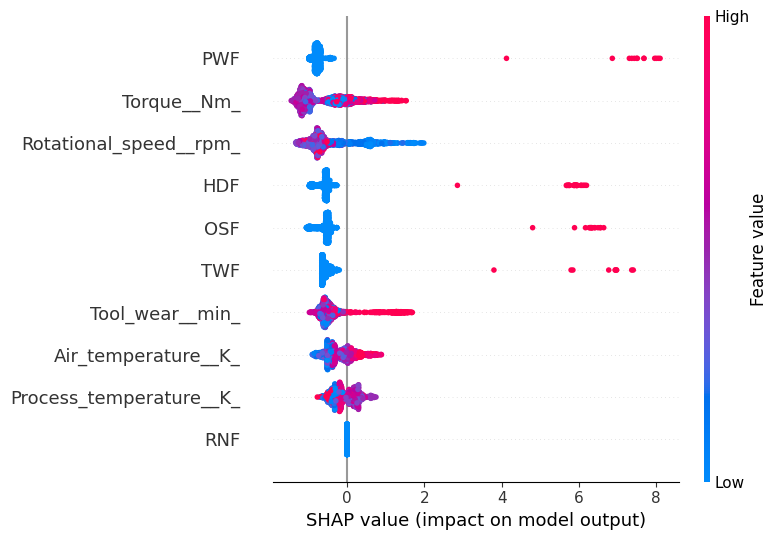

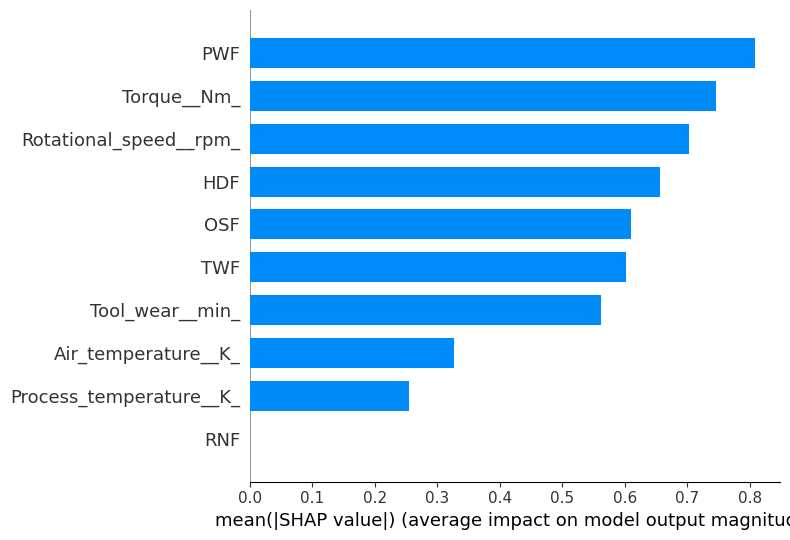

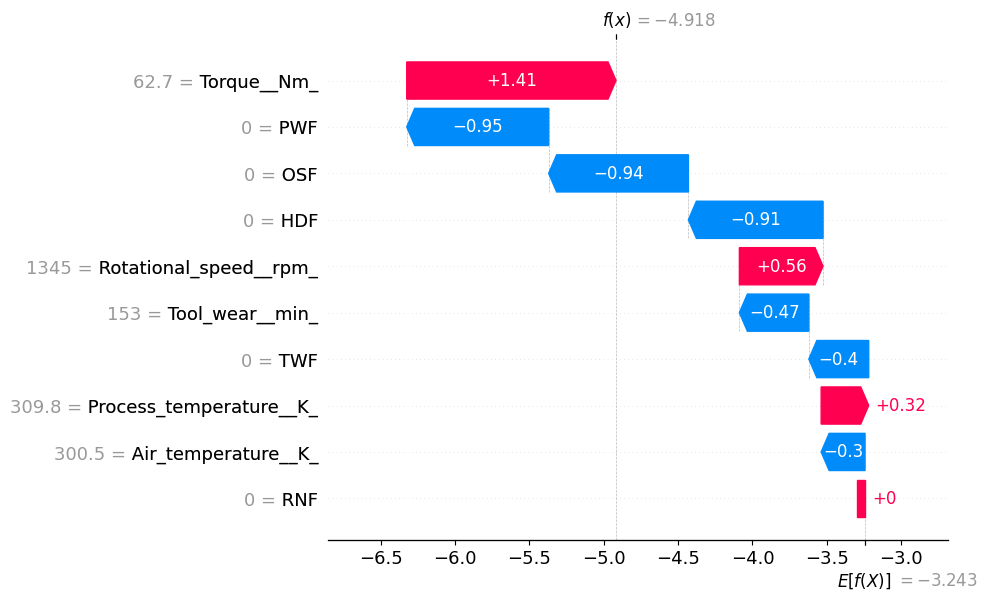

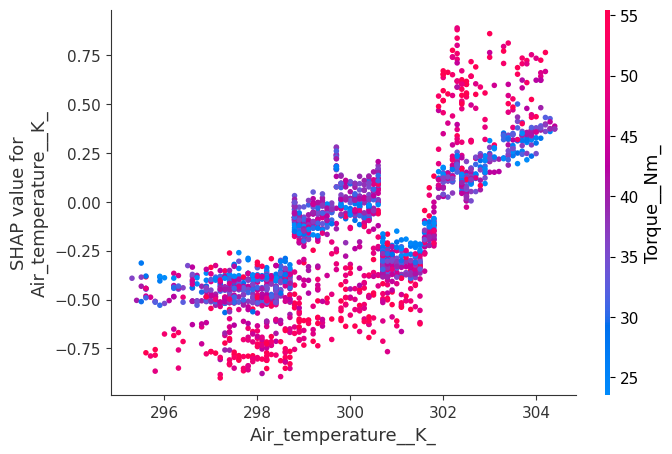

['shap_explainer.pkl']

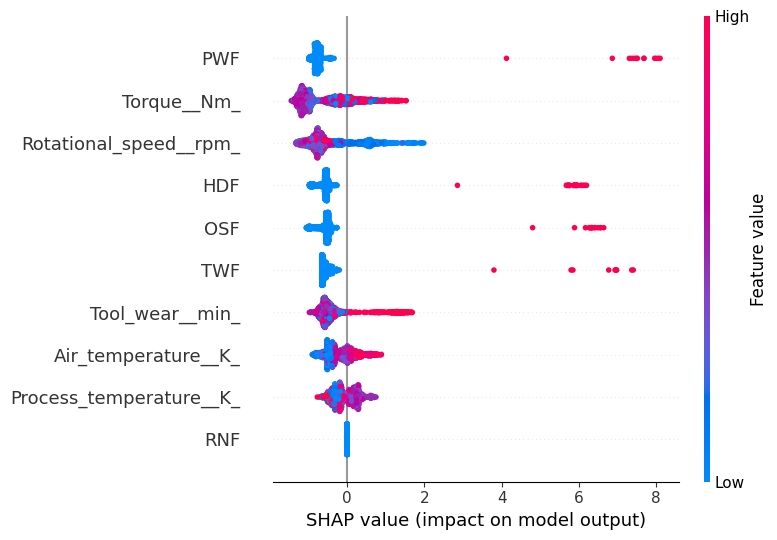

In [41]:
!pip install shap

#Import Libraries
import shap
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
import numpy as np

# Load / Prepare Data
# X_train, X_test, y_train, y_test already exist
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

# Train FINAL TUNED XGBOOST MODEL
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Initialize SHAP Explainer

explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

#SHAP SUMMARY PLOT (Global Importance)

shap.summary_plot(shap_values, X_test)

# SHAP BAR PLOT (Feature Importance Ranking)

shap.summary_plot(shap_values, X_test, plot_type="bar")

#WATERFALL PLOT (Single Prediction)
# Explain first test sample
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0]
))

#FORCE PLOT (Optional - Interactive)
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

#DEPENDENCE PLOT (Feature Interaction)
# Replace 'temperature' with your feature name
feature_name = X_test.columns[0]

shap.dependence_plot(feature_name, shap_values, X_test)

#SAVE SHAP SUMMARY PLOT
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("shap_summary.png", bbox_inches='tight')

# OPTIONAL: SAVE MODEL + EXPLAINER

import joblib

joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(explainer, "shap_explainer.pkl")

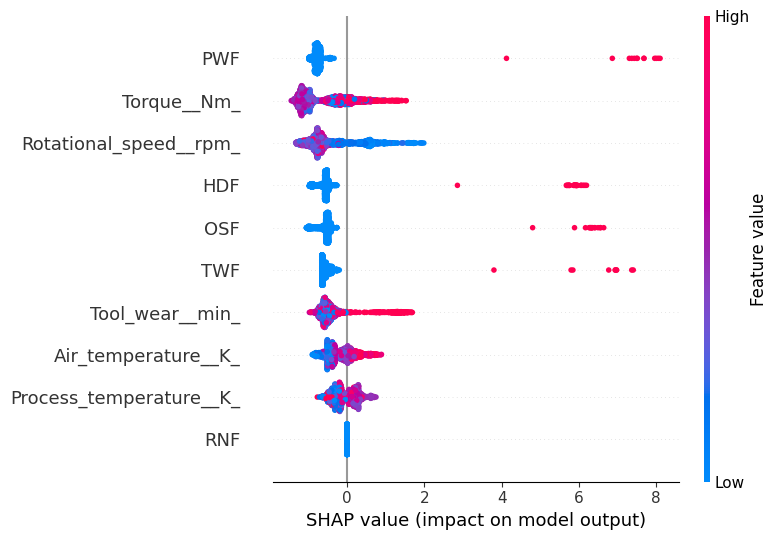

In [42]:
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("shap_summary.png")